# Avaliação de Previsões (Rolling Forecast)

Este notebook avalia previsões salvas em `.csv` na pasta `previsoes/`.

Ele executa três blocos principais:
1. Métricas de avaliação (MAE e MSE) por série e por janela.
2. Box-plots para MAE e MSE (por série e agregado), nos paradigmas **primeira**, **mediana** e **última** previsão.
3. Gráficos de linha das séries (real em preto, predito em vermelho).



In [2]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# =========================
# Utilidades - corrigido
# =========================
def carregar_dados_reais(data_real_path: Path) -> pd.DataFrame:
    """
    Espera um CSV no formato longo com colunas: date, cols, data.
    Retorna DataFrame pivotado com índice datetime e colunas = séries.
    """
    df = pd.read_csv(data_real_path)
    required = {"date", "cols", "data"}
    faltantes = required - set(df.columns)
    if faltantes:
        raise ValueError(f"CSV real sem colunas obrigatórias: {faltantes}")

    df["date"] = pd.to_datetime(df["date"])
    pivot = df.pivot(index="date", columns="cols", values="data").sort_index()
    pivot = pivot.ffill().bfill()
    return pivot


def listar_arquivos_previsao(previsoes_dir: Path):
    """Lista arquivos janela_XXXXXX.csv em ordem numérica."""
    arquivos = list(previsoes_dir.glob("janela_*.csv"))
    if not arquivos:
        raise FileNotFoundError(f"Nenhum arquivo janela_*.csv encontrado em {previsoes_dir}")

    def extrair_idx(p: Path):
        m = re.search(r"janela_(\d+)\.csv$", p.name)
        return int(m.group(1)) if m else -1

    return sorted(arquivos, key=extrair_idx)


def carregar_previsoes_long(previsoes_dir: Path) -> pd.DataFrame:
    """
    Concatena todas as janelas em formato longo.
    Espera colunas das séries + coluna obrigatória 'step'.

    Retorna colunas:
      batch, step, series, y_pred
    """
    rows = []
    for arq in listar_arquivos_previsao(previsoes_dir):
        m = re.search(r"janela_(\d+)\.csv$", arq.name)
        batch_idx = int(m.group(1))

        df = pd.read_csv(arq)
        if "step" not in df.columns:
            raise ValueError(f"Arquivo {arq} sem coluna 'step'")

        series_cols = [c for c in df.columns if c != "step"]
        if not series_cols:
            raise ValueError(f"Arquivo {arq} não possui colunas de série")

        long = df.melt(id_vars=["step"], value_vars=series_cols,
                       var_name="series", value_name="y_pred")
        long["batch"] = batch_idx
        rows.append(long[["batch", "step", "series", "y_pred"]])

    pred_long = pd.concat(rows, ignore_index=True)
    return pred_long


def construir_base_avaliacao(pred_long: pd.DataFrame, real_pivot: pd.DataFrame) -> pd.DataFrame:
    """
    Junta previsões com valores reais.
    step é interpretado como posição inteira na série temporal pivotada.
    """
    real_reset = real_pivot.reset_index(drop=False).rename(columns={real_pivot.index.name or "index": "date"})
    real_reset["step"] = np.arange(len(real_reset))
    real_long = real_reset.melt(id_vars=["date", "step"], var_name="series", value_name="y_true")

    base = pred_long.merge(real_long, on=["step", "series"], how="left")
    base = base.dropna(subset=["y_true", "y_pred"]).copy()
    base["resid"] = base["y_true"] - base["y_pred"]
    base["ae"] = base["resid"].abs()
    base["se"] = base["resid"] ** 2
    return base


def selecionar_paradigma(base: pd.DataFrame, paradigma: str) -> pd.DataFrame:
    """Seleciona primeira/mediana/última previsão para cada (step, series)."""
    paradigma = paradigma.lower().strip()
    if paradigma == "first":
        idx = base.groupby(["step", "series"])["batch"].idxmin()
        return base.loc[idx].copy()
    if paradigma == "last":
        idx = base.groupby(["step", "series"])["batch"].idxmax()
        return base.loc[idx].copy()
    if paradigma == "median":
        agg = base.groupby(["step", "series"], as_index=False).agg(
            y_true=("y_true", "first"),
            y_pred=("y_pred", "median"),
            date=("date", "first")
        )
        agg["resid"] = agg["y_true"] - agg["y_pred"]
        agg["ae"] = agg["resid"].abs()
        agg["se"] = agg["resid"] ** 2
        agg["batch"] = np.nan
        return agg
    raise ValueError("PARADIGMA deve ser 'first', 'median' ou 'last'.")


def metricas_por_janela(base: pd.DataFrame):
    """
    MAE e MSE por lote (janela) e série + agregado médio entre séries.
    """
    por_serie = (
        base.groupby(["batch", "series"], as_index=False)
            .agg(MAE=("ae", "mean"), MSE=("se", "mean"))
            .sort_values(["series", "batch"])
    )

    agregado = (
        por_serie.groupby("batch", as_index=False)
                 .agg(MAE=("MAE", "mean"), MSE=("MSE", "mean"))
                 .sort_values("batch")
    )
    agregado["series"] = "AGREGADO_MEDIA_SERIES"

    return por_serie, agregado


def boxplots_metricas(base_sel: pd.DataFrame, titulo_sufixo: str = ""):
    """Box-plots de MAE e MSE por série e agregado."""
    serie_box = base_sel.groupby("series", as_index=False).agg(MAE=("ae", list), MSE=("se", list))

    registros = []
    for _, row in serie_box.iterrows():
        for v in row["MAE"]:
            registros.append({"series": row["series"], "metric": "MAE", "value": v})
        for v in row["MSE"]:
            registros.append({"series": row["series"], "metric": "MSE", "value": v})

    # Agregado (pool de todas as séries)
    for v in base_sel["ae"].values:
        registros.append({"series": "AGREGADO", "metric": "MAE", "value": v})
    for v in base_sel["se"].values:
        registros.append({"series": "AGREGADO", "metric": "MSE", "value": v})

    plot_df = pd.DataFrame(registros)

    fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)
    for ax, metric in zip(axes, ["MAE", "MSE"]):
        data = plot_df[plot_df["metric"] == metric]
        data.boxplot(column="value", by="series", ax=ax, rot=90)
        ax.set_title(f"Box-plot {metric} {titulo_sufixo}")
        ax.set_xlabel("Série")
        ax.set_ylabel(metric)
    plt.suptitle("")
    plt.show()


def plot_metricas_linha(por_serie: pd.DataFrame, agregado: pd.DataFrame):
    """Gráficos de linha de MAE e MSE por janela para cada série + agregado."""
    series = sorted(por_serie["series"].unique())
    for metric in ["MAE", "MSE"]:
        plt.figure(figsize=(12, 5))
        for s in series:
            d = por_serie[por_serie["series"] == s]
            plt.plot(d["batch"], d[metric], alpha=0.35, linewidth=1)

        plt.plot(agregado["batch"], agregado[metric], color="black", linewidth=2.5,
                 label="Agregado (média entre séries)")
        plt.title(f"{metric} por janela de previsão")
        plt.xlabel("Janela (batch)")
        plt.ylabel(metric)
        plt.legend()
        plt.grid(alpha=0.2)
        plt.show()

DATA_FINAL_OBSERVADA = pd.Timestamp("2025-06-06")

def corrigir_datas_por_step(
    df,
    step_col="step",
    date_col="date",
    data_final_observada=DATA_FINAL_OBSERVADA,
    freq="B",
):
    out = df.copy()
    out[step_col] = pd.to_numeric(out[step_col], errors="coerce")
    out = out.dropna(subset=[step_col])
    out[step_col] = out[step_col].astype(int)

    if out.empty:
        out[date_col] = pd.NaT
        return out

    steps = np.sort(out[step_col].unique())
    datas = pd.date_range(end=data_final_observada, periods=len(steps), freq=freq)
    mapa_datas = dict(zip(steps, datas))

    out[date_col] = out[step_col].map(mapa_datas)
    return out

def plot_series_real_vs_pred(base_sel: pd.DataFrame, series_para_plotar=None,points=False):
    """Gráfico de linha da série real (preto) vs predição (vermelho)."""
    series_disponiveis = sorted(base_sel["series"].unique())
    if series_para_plotar is None or len(series_para_plotar) == 0:
        series_para_plotar = series_disponiveis

    for s in series_para_plotar:
        if s not in series_disponiveis:
            print(f"Série '{s}' não encontrada. Pulando.")
            continue

        d = base_sel[base_sel["series"] == s].sort_values("step").copy()
        d = corrigir_datas_por_step(d, step_col="step", date_col="date")

        fig, ax = plt.subplots(figsize=(14, 4))
        ax.plot(d["date"], d["y_true"], color="black", linewidth=1.7, label="Observado")
        ax.plot(d["date"], d["y_pred"], color="red", linewidth=1.2, alpha=0.9, label="Predito")
        if points: 
            ax.scatter(d["date"], d["y_pred"], s=2, color="darkblue",marker="x", zorder=3)
        ax.set_title(f"Série {s}: real (preto) vs predito (vermelho) - {PARADIGMA}")
        ax.set_xlabel("Data")
        ax.set_ylabel("Valor")
        ax.legend()
        ax.grid(alpha=0.2)

        if len(d) > 0:
            n_ticks = min(10, len(d))
            tick_idx = np.linspace(0, len(d) - 1, n_ticks, dtype=int)
            tick_dates = d["date"].iloc[tick_idx]
            ax.set_xticks(tick_dates)
            ax.set_xticklabels(tick_dates.dt.strftime("%Y-%m-%d"), rotation=45, ha="right")

        fig.tight_layout()
        plt.show()

print("Funções de avaliação carregadas.")



Funções de avaliação carregadas.


⚠️ Arquivo de loss de treino não encontrado: ../previsoes/tfb/retornos_financeiro/DUET/lookback_32_corrigido/train_loss.csv
Total de registros previsão-real pareados: 118,125
Séries encontradas: 9
Batches encontrados: 547


,batch,series,MAE,MSE
0,0,B3SA3,0.018506,0.000609
9,1,B3SA3,0.019209,0.000656
18,2,B3SA3,0.020332,0.000699
27,3,B3SA3,0.021759,0.000741
36,4,B3SA3,0.021584,0.000745
45,5,B3SA3,0.021567,0.000755
54,6,B3SA3,0.020351,0.000669
63,7,B3SA3,0.022844,0.000895
72,8,B3SA3,0.020905,0.000745
81,9,B3SA3,0.021155,0.000742


,batch,MAE,MSE,series
0,0,0.013836,0.000313,AGREGADO_MEDIA_SERIES
1,1,0.013559,0.000308,AGREGADO_MEDIA_SERIES
2,2,0.014130,0.000328,AGREGADO_MEDIA_SERIES
3,3,0.014487,0.000337,AGREGADO_MEDIA_SERIES
4,4,0.014346,0.000328,AGREGADO_MEDIA_SERIES
5,5,0.014101,0.000326,AGREGADO_MEDIA_SERIES
6,6,0.013633,0.000300,AGREGADO_MEDIA_SERIES
7,7,0.014458,0.000361,AGREGADO_MEDIA_SERIES
8,8,0.014229,0.000356,AGREGADO_MEDIA_SERIES
9,9,0.014221,0.000354,AGREGADO_MEDIA_SERIES


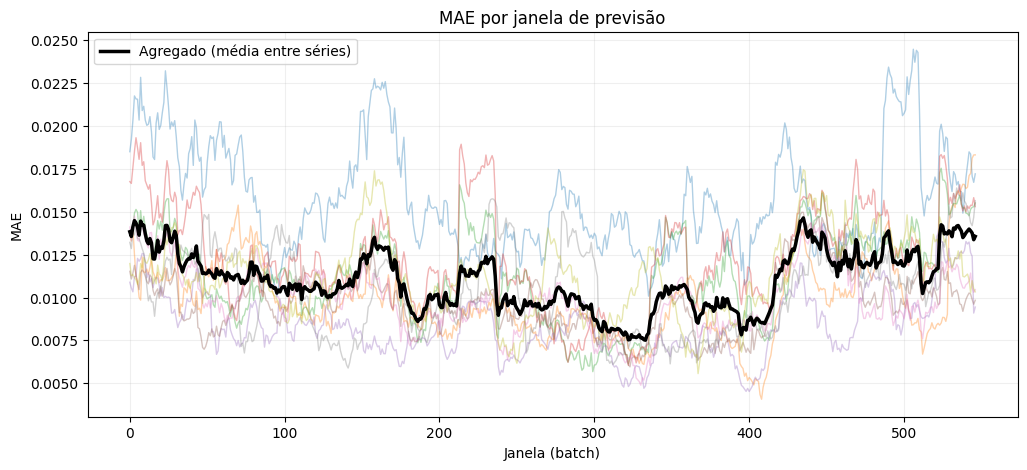

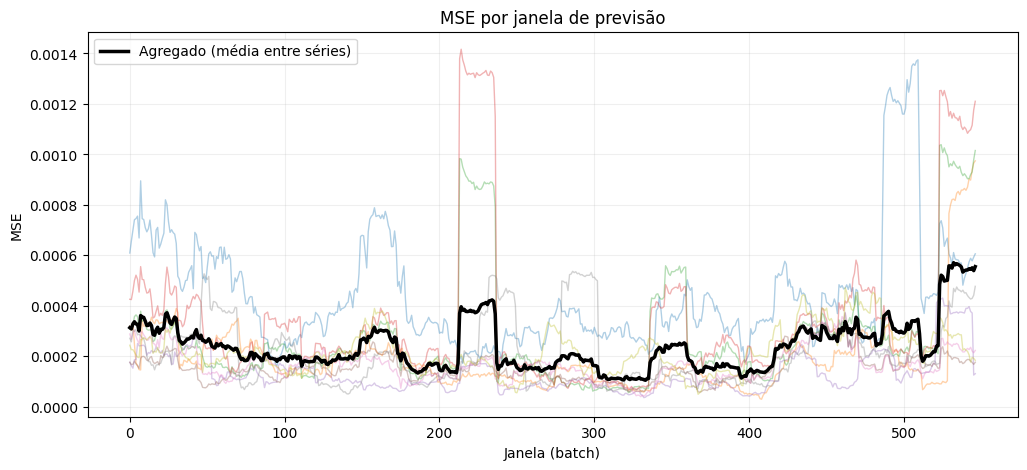

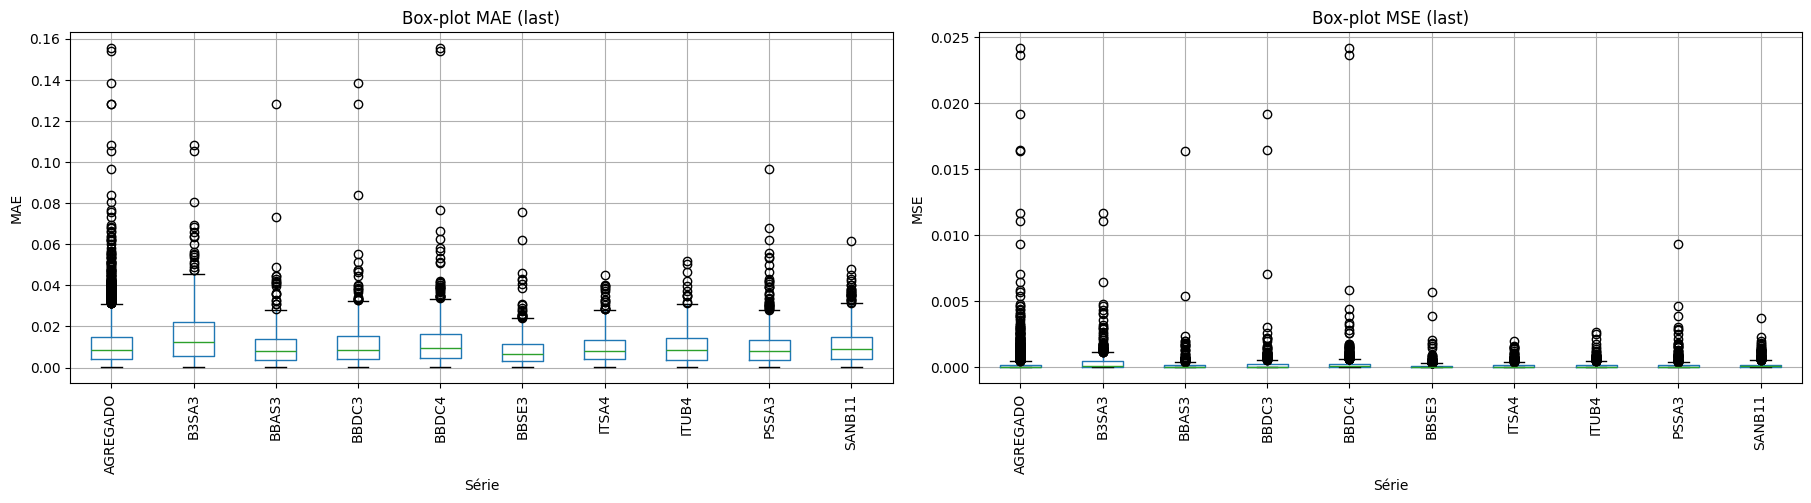

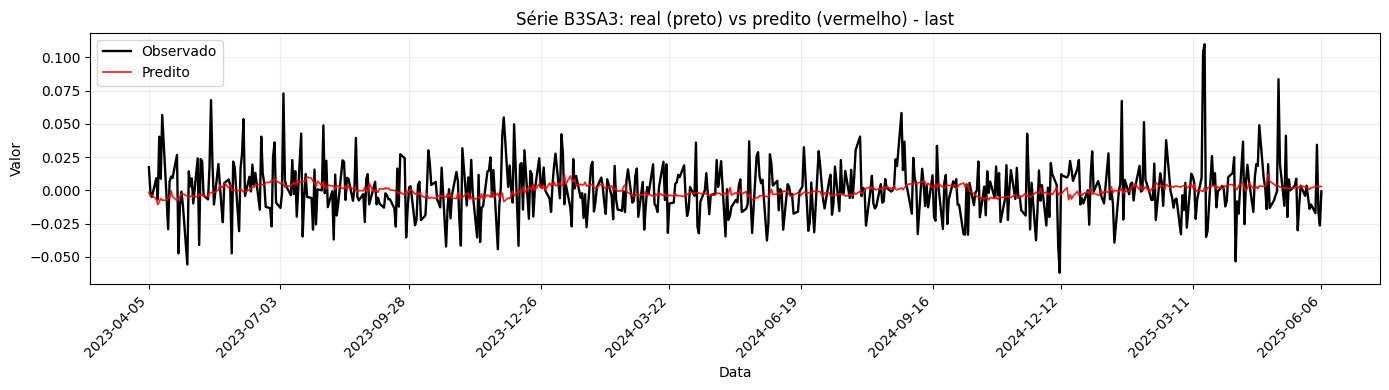

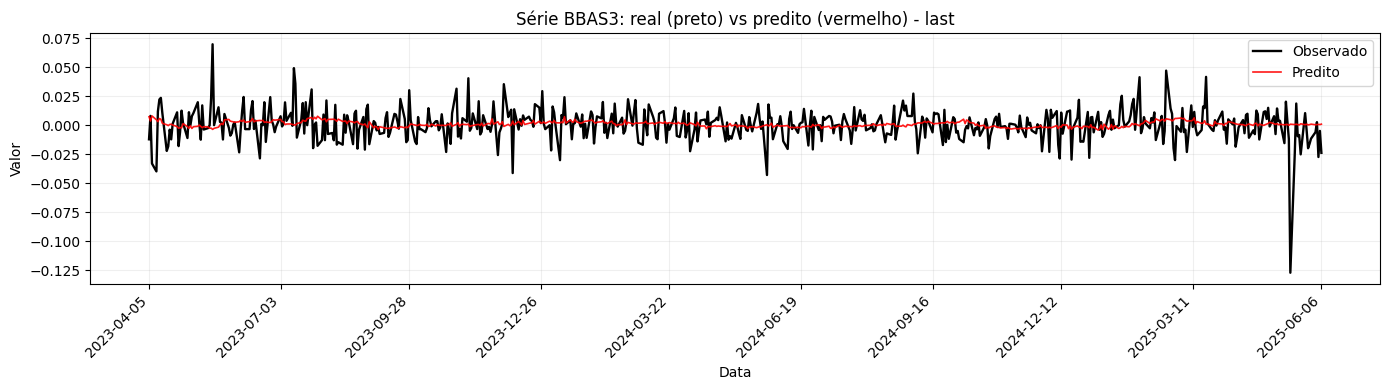

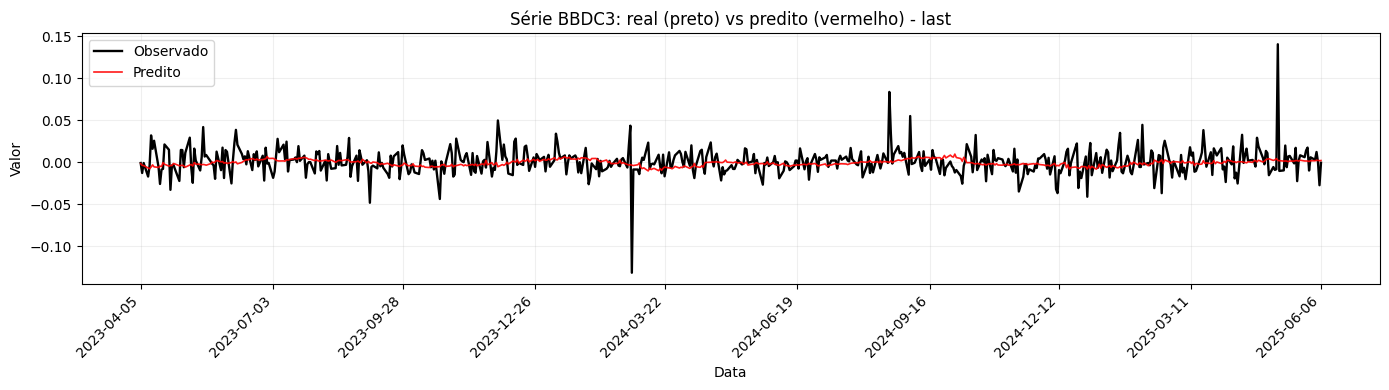

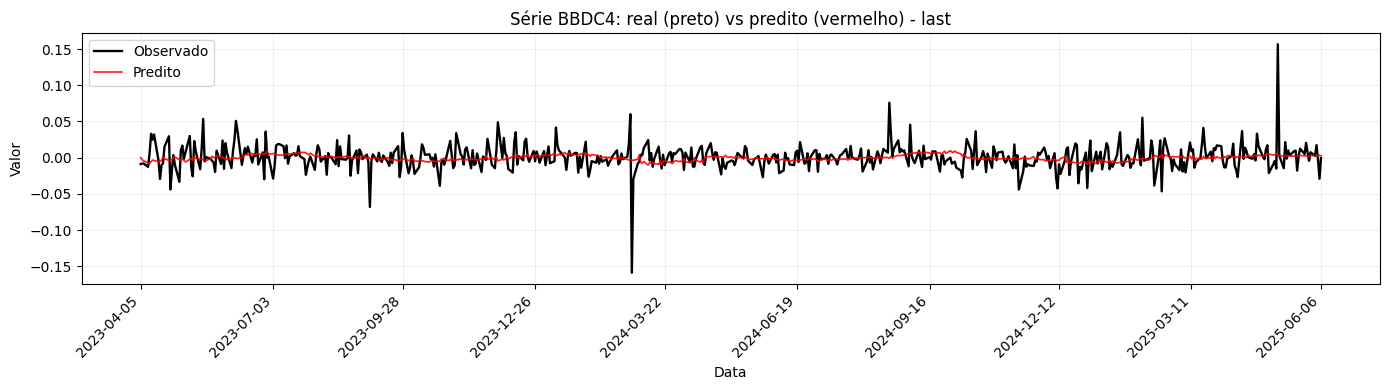

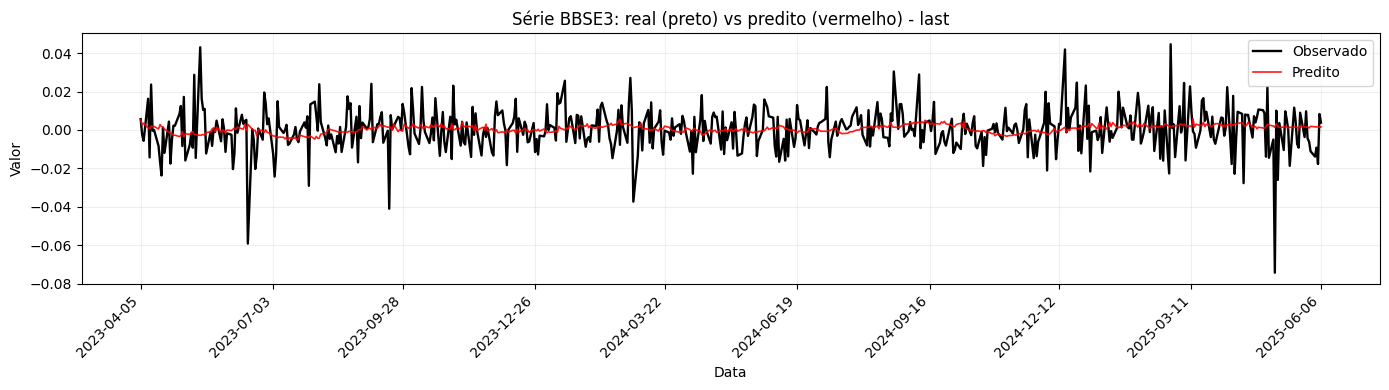

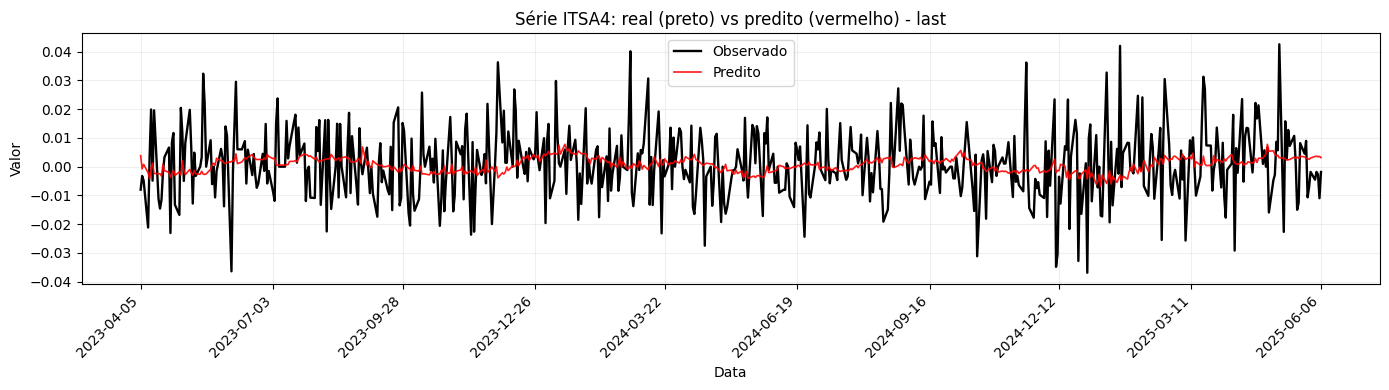

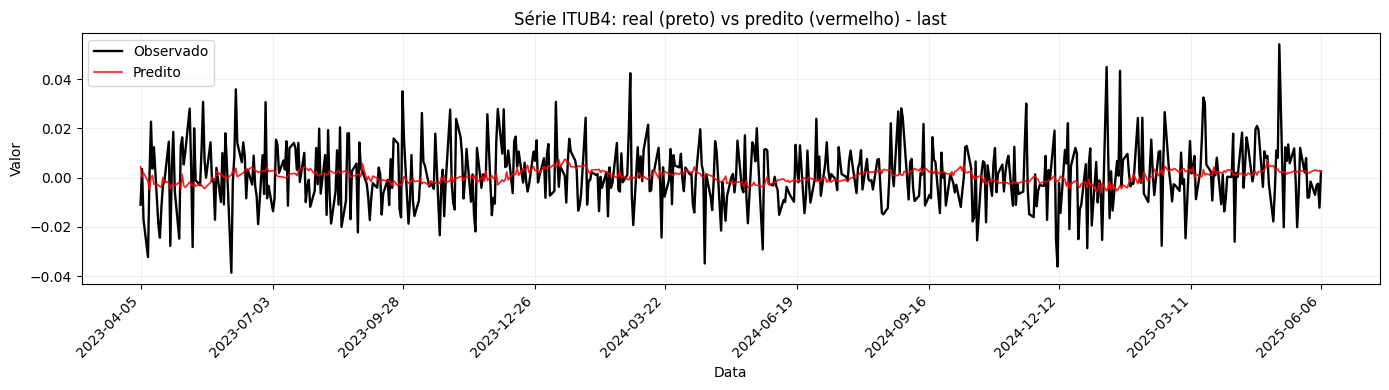

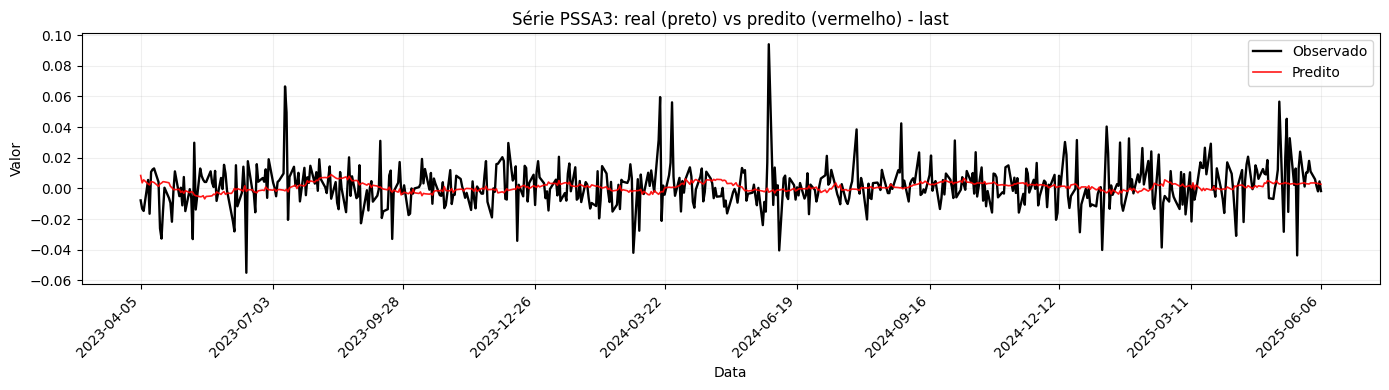

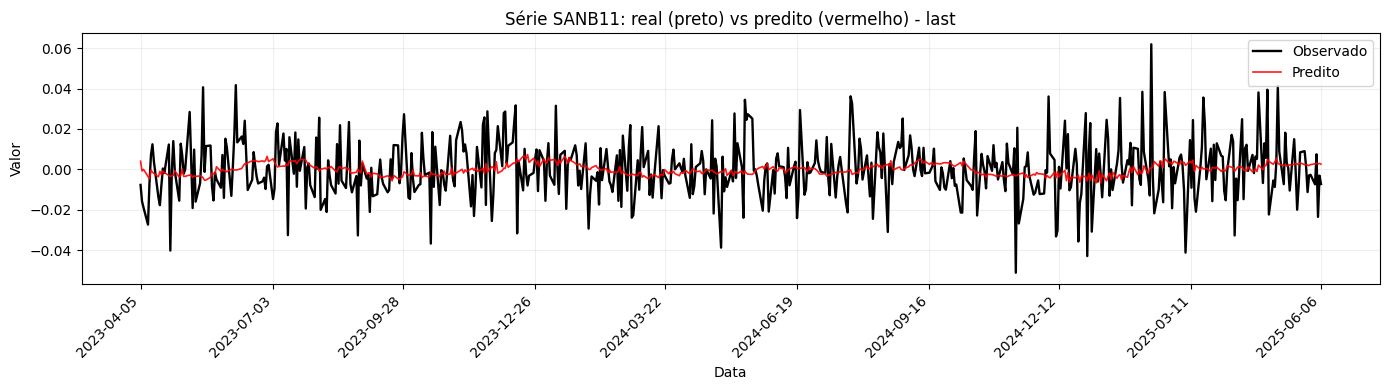

In [8]:

# =========================
# Configuração
# =========================

modelo="DUET"
LB=32

PREVISOES_DIR = Path(f"../previsoes/tfb/financeiro/lookback_{LB}/{modelo}")       # pasta com janela_XXXXXX.csv
DATA_REAL_PATH = Path(f"../data/b3_daily_financeiro.csv")

#PREVISOES_DIR = Path(f"../previsoes/tfb/financeiro_indice/lookback_{LB}/{modelo}")       # pasta com janela_XXXXXX.csv
#DATA_REAL_PATH = Path(f"../data/b3_daily_financeiro_indice.csv")

PREVISOES_DIR = Path(f"../previsoes/tfb/retornos_financeiro/{modelo}/lookback_{LB}_corrigido")       # pasta com janela_XXXXXX.csv
DATA_REAL_PATH = Path(f"../data/b3_daily_return_financeiro.csv")


# =========================
# Loss de treino
# =========================
def plot_train_loss(previsoes_dir: Path):
    train_loss_path = Path(previsoes_dir) / "train_loss.csv"
    if not train_loss_path.exists():
        print(f"⚠️ Arquivo de loss de treino não encontrado: {train_loss_path}")
        return pd.DataFrame()

    loss_df = pd.read_csv(train_loss_path)
    if "train_loss" not in loss_df.columns:
        if "loss" in loss_df.columns:
            loss_df = loss_df.rename(columns={"loss": "train_loss"})
        else:
            raise ValueError("train_loss.csv deve conter coluna 'train_loss' ou 'loss'.")

    if "epoch" not in loss_df.columns:
        loss_df.insert(0, "epoch", np.arange(1, len(loss_df) + 1))

    display(loss_df.head(20))
    plt.figure(figsize=(10, 4))
    plt.plot(loss_df["epoch"], loss_df["train_loss"], marker="o", linewidth=1.8)
    plt.title("Loss de treino por época")
    plt.xlabel("Época")
    plt.ylabel("Train loss")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return loss_df

loss_treino = plot_train_loss(PREVISOES_DIR)

# Paradigma de avaliação da janela deslizante:
#   "first"  -> primeira previsão de cada ponto
#   "median" -> mediana das previsões de cada ponto
#   "last"   -> última previsão de cada ponto
PARADIGMA = "last"

# Se True, mostra gráficos de série para todas as séries.
# Se False, mostra somente as listadas em SERIES_PARA_PLOTAR.
PLOTAR_TODAS_SERIES = False
SERIES_PARA_PLOTAR = []

# =========================
# Execução
# =========================
real_pivot = carregar_dados_reais(DATA_REAL_PATH)
pred_long = carregar_previsoes_long(PREVISOES_DIR)
base = construir_base_avaliacao(pred_long, real_pivot)

print(f"Total de registros previsão-real pareados: {len(base):,}")
print(f"Séries encontradas: {base['series'].nunique()}")
print(f"Batches encontrados: {base['batch'].nunique()}")

# Métricas por janela (lógica original por lote de previsão)
metricas_serie, metricas_agregado = metricas_por_janela(base)

display(metricas_serie.head(20))
display(metricas_agregado.head(20))

plot_metricas_linha(metricas_serie, metricas_agregado)

# Avaliação por paradigma (first / median / last)
base_sel = selecionar_paradigma(base, PARADIGMA)
boxplots_metricas(base_sel, titulo_sufixo=f"({PARADIGMA})")

if PLOTAR_TODAS_SERIES:
    series_plot = sorted(base_sel["series"].unique())
else:
    series_plot = SERIES_PARA_PLOTAR

plot_series_real_vs_pred(base_sel, series_plot, points = False)
